In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
mouse = 29
day = 23

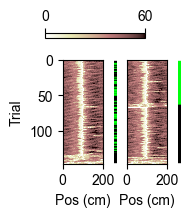

In [3]:
# --- Compute everything for both sort=False and sort=True ---
def get_heatmap_and_colors(beh, last_ephys_bin, tl, bs, sort, trial_cat_priority=None):
    trial_numbers = np.array(beh['trial_number'])
    position = np.array(beh['P'])
    speed = np.array(beh['S'])
    stop_mask = speed < 3

    trial_numbers = trial_numbers[:len(stop_mask)]
    position = position[:len(stop_mask)]
    speed = speed[:len(stop_mask)]

    n_pos_bins = int(tl / 5)
    pos_bins = np.linspace(0, tl, n_pos_bins + 1)

    trial_df = beh['trials'][:int(last_ephys_bin/(tl/bs))]
    if sort:
        sorted_cats = trial_df.groupby(by=['context', 'type', 'performance'])
        if trial_cat_priority is not None:
            sorted_cats = sort_dict_by_priority(sorted_cats, trial_cat_priority)
        sorted_trial_indices = []
        for cat_indices in sorted_cats.values():
            sorted_trial_indices.extend(cat_indices.tolist())
        trial_order = sorted_trial_indices
    else:
        trial_order = trial_df.index.tolist()

    speed_matrix = np.full((len(trial_order), n_pos_bins), np.nan)
    trial_type_colors = []
    for i, ti in enumerate(trial_order):
        trial_num = trial_df['number'][ti]
        mask = (trial_numbers == trial_num)
        pos_trial = position[mask]
        speed_trial = speed[mask]
        bin_sums, _ = np.histogram(pos_trial, bins=pos_bins, weights=speed_trial)
        bin_counts, _ = np.histogram(pos_trial, bins=pos_bins)
        with np.errstate(divide='ignore', invalid='ignore'):
            speed_profile = bin_sums / bin_counts
        speed_matrix[i, :] = speed_profile

        trial_type = trial_df['type'][ti]
        if isinstance(trial_type, str):
            color = get_color_for_group(('rz1', trial_type, 'hit')) if 'get_color_for_group' in globals() else 'grey'
        else:
            color = 'grey'
        trial_type_colors.append(color)
    return speed_matrix, trial_type_colors, trial_order, pos_bins

# --- Prepare data for both sort=False and sort=True ---
_, _, _, last_ephys_bin, beh, _ = compute_vr_tcs(mouse, day)

# You may need to define tl and bs if not already defined in your notebook
# tl = ...
# bs = ...

speed_matrix_unsorted, trial_type_colors_unsorted, trial_order_unsorted, pos_bins = get_heatmap_and_colors(beh, last_ephys_bin, tl, bs, sort=False)
speed_matrix_sorted, trial_type_colors_sorted, trial_order_sorted, _ = get_heatmap_and_colors(beh, last_ephys_bin, tl, bs, sort=True)

# --- Plot 4 columns: heatmap (unsorted), colors (unsorted), heatmap (sorted), colors (sorted) ---
fig, axes = plt.subplots(
    nrows=1, ncols=4,
    figsize=(rm_figsize[0]*2, rm_figsize[1]*1.2),
    gridspec_kw={'width_ratios': [20, 1, 20, 1]}
)

# 1st column: heatmap (unsorted)
ax = axes[0]
mesh = ax.pcolormesh(
    pos_bins, np.arange(len(trial_order_unsorted)+1),
    np.nan_to_num(speed_matrix_unsorted, nan=0),
    cmap='pink_r', shading='auto', vmin=0, vmax=60, 
    rasterized=True
)
ax.set_xlabel('Pos (cm)')
ax.set_ylabel('Trial')
ax.set_xlim(0, tl)
ax.set_ylim(0, len(trial_order_unsorted))
ax.invert_yaxis()
ax.axvspan(90, 110, alpha=0.2, zorder=-10, edgecolor='none', facecolor='grey')
yticks = np.arange(0.5, len(trial_order_unsorted)+0.5, 50)
ax.set_yticks(yticks)
ax.set_yticklabels([str(int(i)) for i in np.arange(0, len(trial_order_unsorted), 50)])

# 2nd column: trial colors (unsorted)
ax_color = axes[1]
for i, color in enumerate(trial_type_colors_unsorted):
    ax_color.scatter(0, i + 0.5, color=color, marker='s', s=20)
ax_color.set_xlim(-0.5, 0.5)
ax_color.set_xticks([])
ax_color.set_yticks([])
ax_color.set_frame_on(False)
ax_color.invert_yaxis()

# 3rd column: heatmap (sorted)
ax2 = axes[2]
mesh2 = ax2.pcolormesh(
    pos_bins, np.arange(len(trial_order_sorted)+1),
    np.nan_to_num(speed_matrix_sorted, nan=0),
    cmap='pink_r', shading='auto', vmin=0, vmax=60,
    rasterized=True
)
ax2.set_xlabel('Pos (cm)')
ax2.set_xlim(0, tl)
ax2.set_ylim(0, len(trial_order_sorted))
ax2.invert_yaxis()
ax2.axvspan(90, 110, alpha=0.2, zorder=-10, edgecolor='none', facecolor='grey')
ax2.set_yticks([])
ax2.set_yticklabels([])

# 4th column: trial colors (sorted)
ax_color2 = axes[3]
for i, color in enumerate(trial_type_colors_sorted):
    ax_color2.scatter(0, i + 0.5, color=color, marker='s', s=20)
ax_color2.set_xlim(-0.5, 0.5)
ax_color2.set_xticks([])
ax_color2.set_yticks([])
ax_color2.set_frame_on(False)
ax_color2.invert_yaxis()

# Add a single horizontal colorbar at the top, with ticks above
cbar_ax = fig.add_axes([0.25, 0.96, 0.5, 0.025])  # [left, bottom, width, height] in figure coordinates
cb = fig.colorbar(mesh, cax=cbar_ax, orientation='horizontal')
cb.set_ticks([0, 60])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(wspace=0.5)
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_behaviour/behaviour_heatmaps_mouse{mouse}_day{day}.pdf', dpi=300)
plt.show()


In [4]:
import os
import pandas as pd
import numpy as np

results = []
for mouse in [20,21,25,26,27,28,29]:
    for day in np.arange(1, 26):
        source_path = '/Users/harryclark/Downloads/COHORT12/'
        vr_folder = f'{source_path}M{mouse}/D{day:02}/VR/'
        beh_path = vr_folder + f"sub-{mouse}_day-{day:02}_ses-VR_beh.nwb"
        if not os.path.exists(beh_path):
            continue
            
        beh = nap.load_file(beh_path)
        trials = beh['trials']
        n_b = len(trials[trials['type'] == 'b'])
        n_nb = len(trials[trials['type'] == 'nb'])
        percentage_hit_b = 100 * len(trials[(trials['type'] == 'b') & (trials['performance'] == 'hit')]) / n_b if n_b else np.nan
        percentage_hit_nb = 100 * len(trials[(trials['type'] == 'nb') & (trials['performance'] == 'hit')]) / n_nb if n_nb else np.nan
        results.append({
            'mouse': mouse,
            'day': day,
            'percentage_hit_b': percentage_hit_b,
            'percentage_hit_nb': percentage_hit_nb
        })

df_hits = pd.DataFrame(results)
df_hits

,mouse,day,percentage_hit_b,percentage_hit_nb
0,20,1,0.000000,0.000000
1,20,2,46.341463,30.000000
2,20,3,72.727273,54.385965
3,20,4,63.529412,44.554455
4,20,5,62.025316,37.500000
...,...,...,...,...
158,29,20,92.857143,93.406593
159,29,21,96.261682,88.659794
160,29,22,97.727273,98.969072
161,29,23,97.014925,91.463415


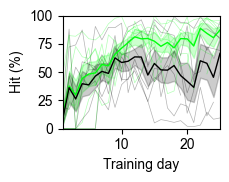

In [5]:
import matplotlib.pyplot as plt

# Ensure 'df_hits' exists and has the columns: mouse, day, percentage_hit_b, percentage_hit_nb

fig, ax = plt.subplots(figsize=(rm_figsize[0]*2.4, rm_figsize[1]*1.2))

# Plot each mouse's line (alpha=0.3)
for mouse, df_mouse in df_hits.groupby('mouse'):
    ax.plot(
        df_mouse['day'], df_mouse['percentage_hit_b'], linewidth=0.5,
        color='#00FF0D', alpha=0.3, label='Beaconed' if mouse == df_hits['mouse'].unique()[0] else ""
    )
    ax.plot(
        df_mouse['day'], df_mouse['percentage_hit_nb'], linewidth=0.5,
        color='black', alpha=0.3, label='Non-beaconed' if mouse == df_hits['mouse'].unique()[0] else ""
    )

# Calculate mean and SEM across mice for each day
days = np.sort(df_hits['day'].unique())
mean_b = df_hits.groupby('day')['percentage_hit_b'].mean()
sem_b = df_hits.groupby('day')['percentage_hit_b'].sem()
mean_nb = df_hits.groupby('day')['percentage_hit_nb'].mean()
sem_nb = df_hits.groupby('day')['percentage_hit_nb'].sem()

# Plot mean with SEM fill (alpha=1 for mean)
ax.plot(days, mean_b, color='#00FF0D', alpha=1, linewidth=1, label='Beaconed (mean)')
ax.fill_between(days, mean_b - sem_b, mean_b + sem_b, color='#00FF0D', alpha=0.2)

ax.plot(days, mean_nb, color='black', alpha=1, linewidth=1, label='Non-beaconed (mean)')
ax.fill_between(days, mean_nb - sem_nb, mean_nb + sem_nb, color='black', alpha=0.2)

ax.set_xlabel('Training day')
ax.set_ylabel('Hit (%)')
ax.set_ylim(0, 100)
ax.set_xlim(1,25)
ax.set_yticks([0,25,50,75,100])
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_behaviour/behaviour_hit_percentage.pdf', dpi=300)
plt.show()